# GR-Prediction — Local Eval (Discretized LSTM)

Evaluates the **CREPE-style discretized LSTM** GR-prediction model locally.
Reads checkpoints, `hparams.json`, and CSV metrics from the Google Drive-synced
run folder. No Colab resources needed.

Features:
- List training runs & checkpoints
- Plot BCE loss + dB MAE curves
- Predict GR on any dry/wet pair and compare to ground truth
- **Bin probability heatmap** — visualise the full 151-bin distribution

> Requirements: `uv sync` at repo root.

In [1]:
# ── 0. Imports and defaults ─────────────────────────────────────────

import os, sys, glob, json, re, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import lightning as pl

warnings.filterwarnings("ignore", category=UserWarning)

from src.dsp_torch import (
    GR_DB_MIN, GR_DB_MAX, RMS_WINDOW,
    gain_reduction_db,
)
from src import dsp_torch

DATA_ROOT = "/Volumes/Saola's Drive/AllCode/thesis/data/Diff-SSL-G-Comp"
RUNS_DIR = "/Volumes/Saola's Drive/AllCode/thesis/data/gr_pred_runs"

# Set SELECTED_RUN_NAME in the run-selection cell after available runs are listed.

SAMPLE_RATE = 44100
DEVICE = "cpu"


from eval_helpers import _checkpoint_sort_key, latest_best_checkpoint, list_runs


print(f"torch {torch.__version__}  |  device: {DEVICE}")
print(f"Shared GR DSP helpers: {dsp_torch.__file__}")

/Volumes/Saola's Drive/AllCode/thesis/Virtual-Analogue-Compressor-Modelling/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch 2.10.0  |  device: cpu
Shared GR DSP helpers: /Volumes/Saola's Drive/AllCode/thesis/Virtual-Analogue-Compressor-Modelling/src/dsp_torch.py


In [2]:
# ── 1. List available discretized LSTM runs ──────────────────────────

assert RUNS_DIR and os.path.isdir(RUNS_DIR), f"RUNS_DIR not found: {RUNS_DIR}"

runs_df = list_runs(RUNS_DIR)
assert not runs_df.empty, "No runs found yet."

available_models_df = runs_df[runs_df["type"] == "frame_rate_lstm_discretized"].copy()
assert not available_models_df.empty, "No discretized LSTM runs found."

display_cols = ["run", "type", "epoch", "best_val", "n_ckpts", "eval_ckpt", "modified"]
print(f"Available discretized LSTM runs: {len(available_models_df)}")
display(available_models_df[display_cols])

Available discretized LSTM runs: 6


,run,type,epoch,best_val,n_ckpts,eval_ckpt,modified
14,lstm_gr_20260520_121432_lstm_v3_discretized,frame_rate_lstm_discretized,135.0,0.075635,31,best-092-4929.ckpt,2026-05-26 11:57:50.604480743
15,lstm_gr_20260520_165452_lstm_v3_discretized_ab...,frame_rate_lstm_discretized,NaN,NaN,0,None,2026-05-26 11:57:50.810888290
16,lstm_gr_20260520_170513_lstm_v3_discretized_ab...,frame_rate_lstm_discretized,NaN,NaN,0,None,2026-05-26 11:57:50.875689507
17,lstm_gr_20260520_170847_lstm_v3_discretized_ab...,frame_rate_lstm_discretized,NaN,NaN,0,None,2026-05-26 11:57:50.939669847
18,lstm_gr_20260524_135723_lstm_v3_discretized_ab...,frame_rate_lstm_discretized,NaN,NaN,0,None,2026-05-26 11:57:51.354297400
19,lstm_gr_20260524_140754_lstm_v3_discretized_ab...,frame_rate_lstm_discretized,160.0,0.051945,36,best-110-31413.ckpt,2026-05-26 11:57:51.416820526


In [3]:
# ── 2. Select run and checkpoint ─────────────────────────────────────

SELECTED_RUN_NAME = "lstm_gr_20260520_121432_lstm_v3_discretized"

matches = available_models_df[available_models_df["run"] == SELECTED_RUN_NAME]
assert len(matches) == 1, f"Run not found in available discretized LSTM runs: {SELECTED_RUN_NAME}"
selected_run = matches.iloc[0]

RUN_NAME = str(selected_run["run"])
RUN_DIR = os.path.join(RUNS_DIR, RUN_NAME)
CKPT_DIR = os.path.join(RUN_DIR, "checkpoints")
HPARAMS_PATH = os.path.join(RUN_DIR, "hparams.json")
EVAL_CKPT_PATH = latest_best_checkpoint(RUN_DIR)

print(f"Selected run   : {RUN_NAME}")
print(f"Model type     : {selected_run['type']}")
print(f"Eval checkpoint: {os.path.basename(EVAL_CKPT_PATH)}")
if pd.notna(selected_run.get("best_val")):
    print(f"Best val loss  : {selected_run['best_val']:.6f}")

Selected run   : lstm_gr_20260520_121432_lstm_v3_discretized
Model type     : frame_rate_lstm_discretized
Eval checkpoint: best-092-4929.ckpt
Best val loss  : 0.075635


In [4]:
# ── 2. Inspect checkpoints ──────────────────────────────────────────

print(f"Selected run   : {RUN_NAME}")
print(f"Eval checkpoint: {os.path.basename(EVAL_CKPT_PATH)}")
print("Checkpoints    :")
for c in sorted(glob.glob(os.path.join(CKPT_DIR, "*.ckpt")), key=_checkpoint_sort_key):
    marker = " <-- eval" if os.path.abspath(c) == os.path.abspath(EVAL_CKPT_PATH) else ""
    sz = os.path.getsize(c) / 1e6
    print(f"  {os.path.basename(c):<36}  {sz:6.2f} MB{marker}")

Selected run   : lstm_gr_20260520_121432_lstm_v3_discretized
Eval checkpoint: best-092-4929.ckpt
Checkpoints    :
  last.ckpt                               1.05 MB
  epoch-004.ckpt                          1.05 MB
  epoch-009.ckpt                          1.05 MB
  epoch-014.ckpt                          1.05 MB
  epoch-019.ckpt                          1.05 MB
  epoch-024.ckpt                          1.05 MB
  epoch-029.ckpt                          1.05 MB
  epoch-034.ckpt                          1.05 MB
  epoch-039.ckpt                          1.05 MB
  epoch-044.ckpt                          1.05 MB
  epoch-049.ckpt                          1.05 MB
  epoch-054.ckpt                          1.05 MB
  epoch-059.ckpt                          1.05 MB
  epoch-064.ckpt                          1.05 MB
  epoch-069.ckpt                          1.05 MB
  epoch-074.ckpt                          1.05 MB
  epoch-079.ckpt                          1.05 MB
  epoch-084.ckpt                    

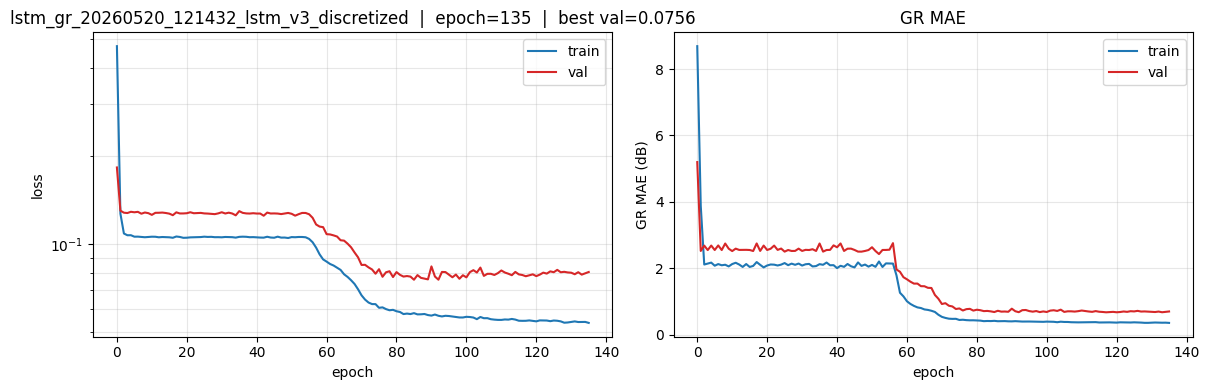

In [5]:
# ── 3. Loss curves ──────────────────────────────────────────────────

def plot_loss_curves(run_dir=None, ymin=None):
    run_dir = run_dir or RUN_DIR
    csv_path = os.path.join(run_dir, "csv", "metrics.csv")
    if not os.path.exists(csv_path):
        print(f"No metrics.csv yet at {csv_path}")
        return
    df = pd.read_csv(csv_path)

    has_mae = "mae_db/val" in df.columns and df["mae_db/val"].notna().any()
    n_cols = 2 if has_mae else 1

    fig, axes = plt.subplots(1, n_cols, figsize=(8 * n_cols, 5))
    if n_cols == 1:
        axes = [axes]

    # BCE loss
    ax = axes[0]
    train = df.dropna(subset=["loss/train"])[["epoch", "loss/train"]]
    val = df.dropna(subset=["loss/val"])[["epoch", "loss/val"]]
    ax.plot(train["epoch"], train["loss/train"], label="train", lw=1.5, color="#1f77b4")
    ax.plot(val["epoch"], val["loss/val"], label="val", lw=1.5, color="#d62728")
    ax.set_xlabel("epoch")
    ax.set_ylabel("BCE loss")
    ax.set_yscale("log")
    ax.grid(alpha=0.3, which="both")
    ax.legend()
    last_epoch = int(max(train["epoch"].max() if len(train) else -1,
                         val["epoch"].max() if len(val) else -1))
    best_val = float(val["loss/val"].min()) if len(val) else float("nan")
    ax.set_title(f"BCE loss | epoch={last_epoch} | best val={best_val:.4f}")
    if ymin is not None:
        ax.set_ylim(bottom=ymin)

    # dB MAE
    if has_mae:
        ax2 = axes[1]
        mae_tr = df.dropna(subset=["mae_db/train"])[["epoch", "mae_db/train"]]
        mae_va = df.dropna(subset=["mae_db/val"])[["epoch", "mae_db/val"]]
        ax2.plot(mae_tr["epoch"], mae_tr["mae_db/train"], label="train", lw=1.5, color="#1f77b4")
        ax2.plot(mae_va["epoch"], mae_va["mae_db/val"], label="val", lw=1.5, color="#d62728")
        ax2.set_xlabel("epoch")
        ax2.set_ylabel("MAE (dB)")
        ax2.grid(alpha=0.3)
        ax2.legend()
        best_mae = float(mae_va["mae_db/val"].min()) if len(mae_va) else float("nan")
        ax2.set_title(f"dB MAE | best val={best_mae:.2f} dB")

    fig.suptitle(os.path.basename(run_dir), fontsize=11)
    plt.tight_layout()
    plt.show()
    return df

from eval_helpers import plot_loss_curves

_ = plot_loss_curves(RUN_DIR)

In [6]:
# ── 4. Model definitions & checkpoint loading ───────────────────────

# ── Discretization constants (must match training notebook) ──────────

GR_NUM_BINS = 151
GR_BIN_RESOLUTION = 0.2
GR_BIN_CENTERS = torch.linspace(GR_DB_MIN, GR_DB_MAX, GR_NUM_BINS)


def logits_to_local_avg_db(logits, window=5):
    probs = torch.sigmoid(logits)
    centers = GR_BIN_CENTERS.to(logits.device)
    peak = probs.argmax(dim=1)
    B, N, T = probs.shape
    bin_idx = torch.arange(N, device=logits.device).view(1, N, 1).expand(B, N, T)
    lo = (peak.unsqueeze(1) - window).clamp(min=0)
    hi = (peak.unsqueeze(1) + window + 1).clamp(max=N)
    mask = (bin_idx >= lo) & (bin_idx < hi)
    masked_probs = probs * mask
    weighted = (masked_probs * centers[None, :, None]).sum(dim=1, keepdim=True)
    total = masked_probs.sum(dim=1, keepdim=True).clamp(min=1e-8)
    return weighted / total


# ── Discretized LSTM model (matches train_lstm_nocond_discretized) ───

class FrameRateLSTMGR(nn.Module):
    def __init__(self, hop_size=256, encoder_channels=32, hidden_size=64,
                 num_layers=2, dropout=0.0, num_bins=GR_NUM_BINS):
        super().__init__()
        self.hop_size = hop_size
        self.num_bins = num_bins
        self.rf = hop_size * 4
        ks = hop_size * 2
        self.encoder = nn.Sequential(
            nn.Conv1d(1, encoder_channels, ks, stride=hop_size, padding=ks // 2),
            nn.PReLU(encoder_channels),
            nn.Conv1d(encoder_channels, encoder_channels, 3, padding=1),
            nn.PReLU(encoder_channels),
        )
        self.lstm = nn.LSTM(
            encoder_channels, hidden_size, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Linear(hidden_size // 2, num_bins),
        )

    def forward(self, x):
        feat = self.encoder(x)
        feat = feat.transpose(1, 2)
        h, _ = self.lstm(feat)
        logits = self.head(h)
        return logits.transpose(1, 2)

    def to_db(self, logits, T=None):
        db = logits_to_local_avg_db(logits)
        if T is not None:
            db = F.interpolate(db, size=T, mode="linear", align_corners=False)
        return db

    def reset_states(self):
        pass


# ── Lightning system (matches training notebook constructor) ─────────

class GRPredictionLSTM(pl.LightningModule):
    def __init__(self, model, lr=1e-3, sigma_bins=2.0, warmup_frames=4,
                 lr_patience=20, min_lr=1e-6):
        super().__init__()
        self.model = model
        self.lr = lr
        self.sigma_bins = sigma_bins
        self.warmup_frames = warmup_frames
        self.lr_patience = lr_patience
        self.min_lr = min_lr

    def forward(self, x):
        return self.model(x)

    def configure_optimizers(self):
        opt = torch.optim.AdamW(self.parameters(), lr=self.lr)
        sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
            opt, mode="min", factor=0.5, patience=self.lr_patience, min_lr=self.min_lr,
        )
        return {"optimizer": opt, "lr_scheduler": {"scheduler": sched, "monitor": "loss/val"}}


# ── Checkpoint loading ───────────────────────────────────────────────

from eval_helpers import _find_hparams_json


def build_lstm_from_hparams(hp):
    h = hp["lstm"]
    d = hp.get("discretization", {})
    return FrameRateLSTMGR(
        hop_size=h["hop_size"],
        encoder_channels=h["encoder_channels"],
        hidden_size=h["hidden_size"],
        num_layers=h["num_layers"],
        dropout=h.get("dropout", 0.0),
        num_bins=d.get("num_bins", GR_NUM_BINS),
    )


def load_system_from_ckpt(ckpt_path, hparams_path=None):
    if hparams_path is None:
        hparams_path = _find_hparams_json(ckpt_path)
    assert hparams_path and os.path.isfile(hparams_path), (
        f"hparams.json not found near {ckpt_path}"
    )
    with open(hparams_path) as f:
        hp = json.load(f)

    expected_hash = hp.get("src_dsp_torch_sha256")
    if expected_hash:
        import hashlib as _hl
        local_hash = _hl.sha256(Path(dsp_torch.__file__).read_bytes()).hexdigest()
        if local_hash != expected_hash:
            print("[warning] local src.dsp_torch differs from checkpoint's version")

    model = build_lstm_from_hparams(hp)
    loss_hp = hp.get("loss", {})
    system = GRPredictionLSTM.load_from_checkpoint(
        ckpt_path, model=model, map_location=DEVICE,
        lr=hp.get("lr", 1e-3),
        sigma_bins=loss_hp.get("sigma_bins", 2.0),
        warmup_frames=loss_hp.get("warmup_frames", 4),
        lr_patience=hp.get("lr_plateau_patience", 20),
        min_lr=hp.get("min_lr", 1e-6),
    )
    system.to(DEVICE)
    system.eval()
    return system, hp


print("Model builder registered: frame_rate_lstm_discretized")

Model builder registered: frame_rate_lstm_discretized


In [7]:
# ── 5. Evaluation & visualisation functions ──────────────────────────

def same_setting_pairs(data_root, setting):
    dry_dir = os.path.join(data_root, "processed_normalized")
    wet_dir = os.path.join(data_root, "processed_ground_truth", setting)
    assert os.path.isdir(dry_dir), f"Missing: {dry_dir}"
    assert os.path.isdir(wet_dir), f"Missing: {wet_dir}"
    dry_lookup = {
        os.path.basename(p).replace("_UnmasteredWAV.wav", ""): p
        for p in sorted(glob.glob(os.path.join(dry_dir, "*_UnmasteredWAV.wav")))
    }
    pairs = []
    for wet_path in sorted(glob.glob(os.path.join(wet_dir, "*-exported.wav"))):
        song = os.path.basename(wet_path).replace("-exported.wav", "")
        if song in dry_lookup:
            pairs.append((dry_lookup[song], wet_path))
    assert pairs, f"No pairs for {setting}"
    return pairs


from eval_helpers import _read_dry_wet_segment, same_setting_pairs


@torch.no_grad()
def predict_gr_curves(
    ckpt_path,
    dry_wav_path,
    wet_wav_path,
    start_sec=0.0,
    duration_sec=6.0,
    hparams_path=None,
    pre_roll_sec=None,
):
    system, hp = load_system_from_ckpt(ckpt_path, hparams_path)
    sr = int(hp["sample_rate"])
    rms_win = int(hp["rms_window"])
    hop = hp["lstm"]["hop_size"]
    rf_samples = hop * 4

    start = int(round(start_sec * sr))
    stop = start + int(round(duration_sec * sr))
    pre_roll = rf_samples if pre_roll_sec is None else int(round(pre_roll_sec * sr))
    context_start = max(0, start - pre_roll)
    context_offset = start - context_start

    dry, wet = _read_dry_wet_segment(dry_wav_path, wet_wav_path, context_start, stop, sr)

    gr_target_db = gain_reduction_db(
        dry.unsqueeze(0), wet.unsqueeze(0), rms_win
    ).squeeze(0).clamp(GR_DB_MIN, GR_DB_MAX)

    x = dry.unsqueeze(0).to(DEVICE)
    if hasattr(system.model, "reset_states"):
        system.model.reset_states()
    logits = system(x)
    gr_pred_db = system.model.to_db(logits, T=dry.shape[-1]).squeeze(0)

    n = min(stop - start, dry.shape[-1] - context_offset,
            gr_target_db.shape[-1] - context_offset,
            gr_pred_db.shape[-1] - context_offset)
    assert n > 0
    w = slice(context_offset, context_offset + n)

    gr_true = gr_target_db[..., w].squeeze().cpu().numpy()
    gr_pred = gr_pred_db[..., w].squeeze().cpu().numpy()
    dry_wave = dry[..., w].squeeze().cpu().numpy()

    probs_full = torch.sigmoid(logits).squeeze(0).cpu()
    frame_start = context_offset // hop
    frame_end = min((context_offset + n) // hop + 1, probs_full.shape[1])
    bin_probs = probs_full[:, frame_start:frame_end].numpy()

    err = gr_pred - gr_true
    song = os.path.basename(dry_wav_path).replace("_UnmasteredWAV.wav", "")

    return {
        "song": song, "setting": hp["setting"],
        "model_type": hp.get("model_type", "frame_rate_lstm_discretized"),
        "ckpt": ckpt_path, "sample_rate": sr,
        "start_sec": start_sec, "duration_sec": n / sr,
        "pre_roll_sec": context_offset / sr,
        "time": np.arange(n) / sr,
        "dry": dry_wave, "gr_true": gr_true, "gr_pred": gr_pred,
        "error": err,
        "mae_db": float(np.mean(np.abs(err))),
        "rmse_db": float(np.sqrt(np.mean(err ** 2))),
        "bin_probs": bin_probs,
        "hop_size": hop,
        "hparams": hp,
    }


@torch.no_grad()
def visualize_prediction(
    ckpt_path,
    dry_wav_path=None,
    wet_wav_path=None,
    start_sec=0.0,
    duration_sec=6.0,
    hparams_path=None,
    pre_roll_sec=None,
    title=None,
    show_heatmap=True,
):
    system, hp = load_system_from_ckpt(ckpt_path, hparams_path)
    setting = hp["setting"]
    pairs = same_setting_pairs(DATA_ROOT, setting)
    if dry_wav_path is None:
        dry_wav_path, wet_wav_path = pairs[0]
    elif wet_wav_path is None:
        song = os.path.basename(dry_wav_path).replace("_UnmasteredWAV.wav", "")
        wet_wav_path = os.path.join(
            DATA_ROOT, "processed_ground_truth", setting, f"{song}-exported.wav"
        )

    curves = predict_gr_curves(
        ckpt_path=ckpt_path, dry_wav_path=dry_wav_path, wet_wav_path=wet_wav_path,
        start_sec=start_sec, duration_sec=duration_sec,
        hparams_path=hparams_path, pre_roll_sec=pre_roll_sec,
    )

    t = curves["time"]
    n_rows = 4 if show_heatmap else 3
    ratios = [1, 2, 1, 2] if show_heatmap else [1, 2, 1]
    fig, axes = plt.subplots(
        n_rows, 1, figsize=(11, 3 * n_rows - 2), sharex=True,
        gridspec_kw={"height_ratios": ratios},
    )

    axes[0].plot(t, curves["dry"], lw=0.6, color="#444")
    axes[0].set_ylabel("dry")
    axes[0].set_ylim(-1.05, 1.05)
    axes[0].grid(alpha=0.3)

    axes[1].plot(t, curves["gr_true"], label="target", lw=1.4, color="#1f77b4")
    axes[1].plot(t, curves["gr_pred"], label="prediction", lw=1.2, color="#d62728", alpha=0.85)
    axes[1].axhline(0, color="k", lw=0.5, alpha=0.4)
    axes[1].set_ylabel("GR (dB)")
    axes[1].legend(loc="lower right")
    axes[1].grid(alpha=0.3)

    axes[2].plot(t, curves["error"], lw=0.8, color="#2ca02c")
    axes[2].axhline(0, color="k", lw=0.5, alpha=0.4)
    axes[2].set_ylabel("error (dB)")
    axes[2].grid(alpha=0.3)

    if show_heatmap:
        probs = curves["bin_probs"]
        extent = [t[0], t[-1], GR_DB_MIN, GR_DB_MAX]
        im = axes[3].imshow(
            probs, aspect="auto", origin="lower", extent=extent,
            cmap="magma", vmin=0, vmax=1, interpolation="bilinear",
        )
        axes[3].plot(t, curves["gr_true"], color="cyan", lw=0.8, alpha=0.8, label="target")
        axes[3].plot(t, curves["gr_pred"], color="lime", lw=0.8, alpha=0.8, label="predicted")
        axes[3].set_ylabel("GR (dB)")
        axes[3].legend(loc="lower right", fontsize=8)
        fig.colorbar(im, ax=axes[3], label="P(bin)", shrink=0.8)

    axes[-1].set_xlabel("time (s)")

    ttl = title or (
        f"{curves['song']}  |  {curves['model_type']}  |  {curves['setting']}\n"
        f"ckpt={os.path.basename(ckpt_path)}  "
        f"pre-roll={curves['pre_roll_sec']:.2f}s  "
        f"MAE={curves['mae_db']:.2f} dB  RMSE={curves['rmse_db']:.2f} dB"
    )
    fig.suptitle(ttl, fontsize=10)
    plt.tight_layout()
    plt.show()
    return curves


def compare_same_setting_curves(
    ckpt_path,
    start_sec=30.0,
    duration_sec=5.0,
    max_pairs=2,
    start_pair=5,
    hparams_path=None,
    show_heatmap=True,
):
    _, hp = load_system_from_ckpt(ckpt_path, hparams_path)
    pairs = same_setting_pairs(DATA_ROOT, hp["setting"])
    selected = pairs[start_pair:max_pairs + start_pair]
    print(f"Comparing {len(selected)} of {len(pairs)} pairs")
    return [
        visualize_prediction(
            ckpt_path=ckpt_path, dry_wav_path=d, wet_wav_path=w,
            start_sec=start_sec, duration_sec=duration_sec,
            hparams_path=hparams_path, show_heatmap=show_heatmap,
        )
        for d, w in selected
    ]

## Usage

Re-run the cells below any time; they read the latest synced files from Drive.
Use the available-runs cell first, then set `SELECTED_RUN_NAME` in the following selection cell.

Set `show_heatmap=False` to hide the bin probability panel.

Running best-092-4929.ckpt
[warning] local src.dsp_torch differs from checkpoint's version
[warning] local src.dsp_torch differs from checkpoint's version


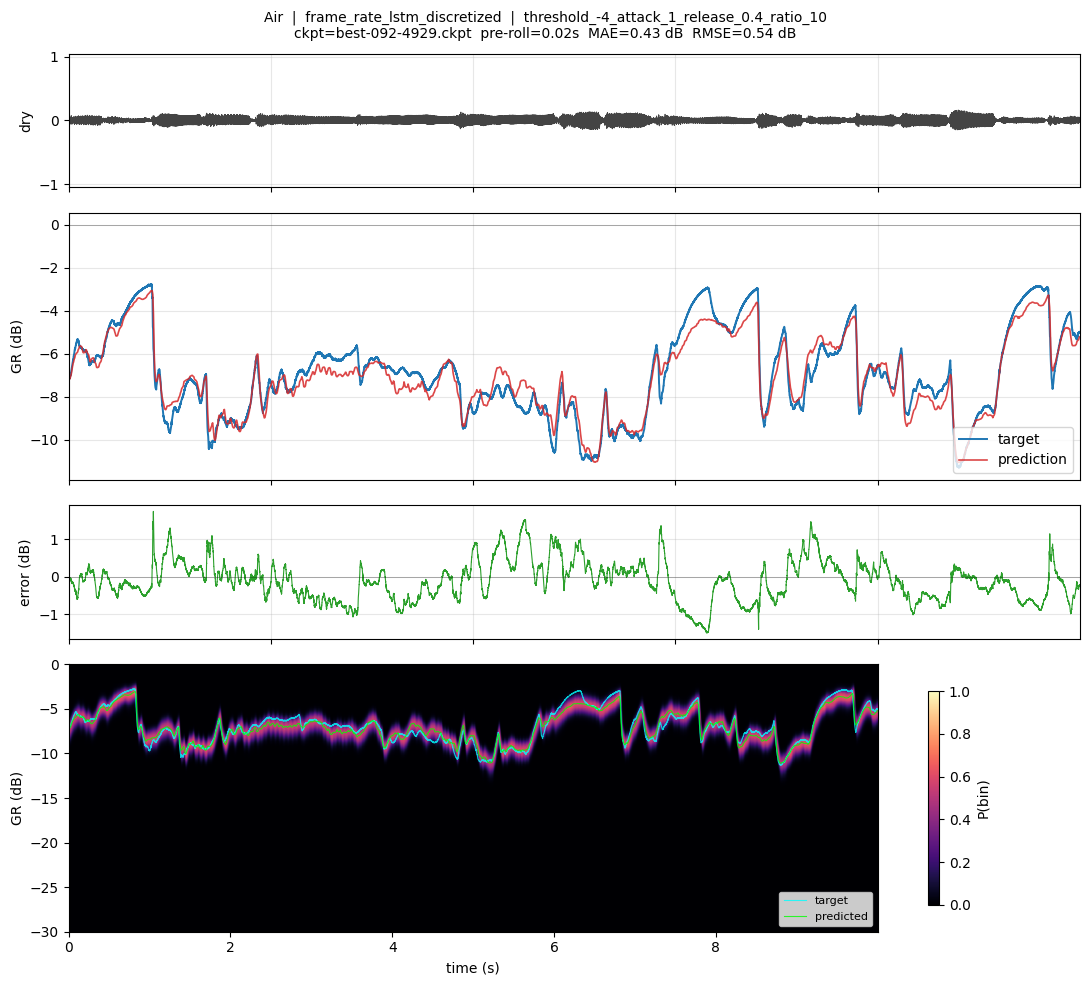

In [8]:
# Single prediction preview
print(f"Running {os.path.basename(EVAL_CKPT_PATH)}")

_ = visualize_prediction(
    ckpt_path=EVAL_CKPT_PATH,
    start_sec=30.0,
    duration_sec=10.0,
)

[warning] local src.dsp_torch differs from checkpoint's version
Comparing 3 of 10 pairs
[warning] local src.dsp_torch differs from checkpoint's version
[warning] local src.dsp_torch differs from checkpoint's version


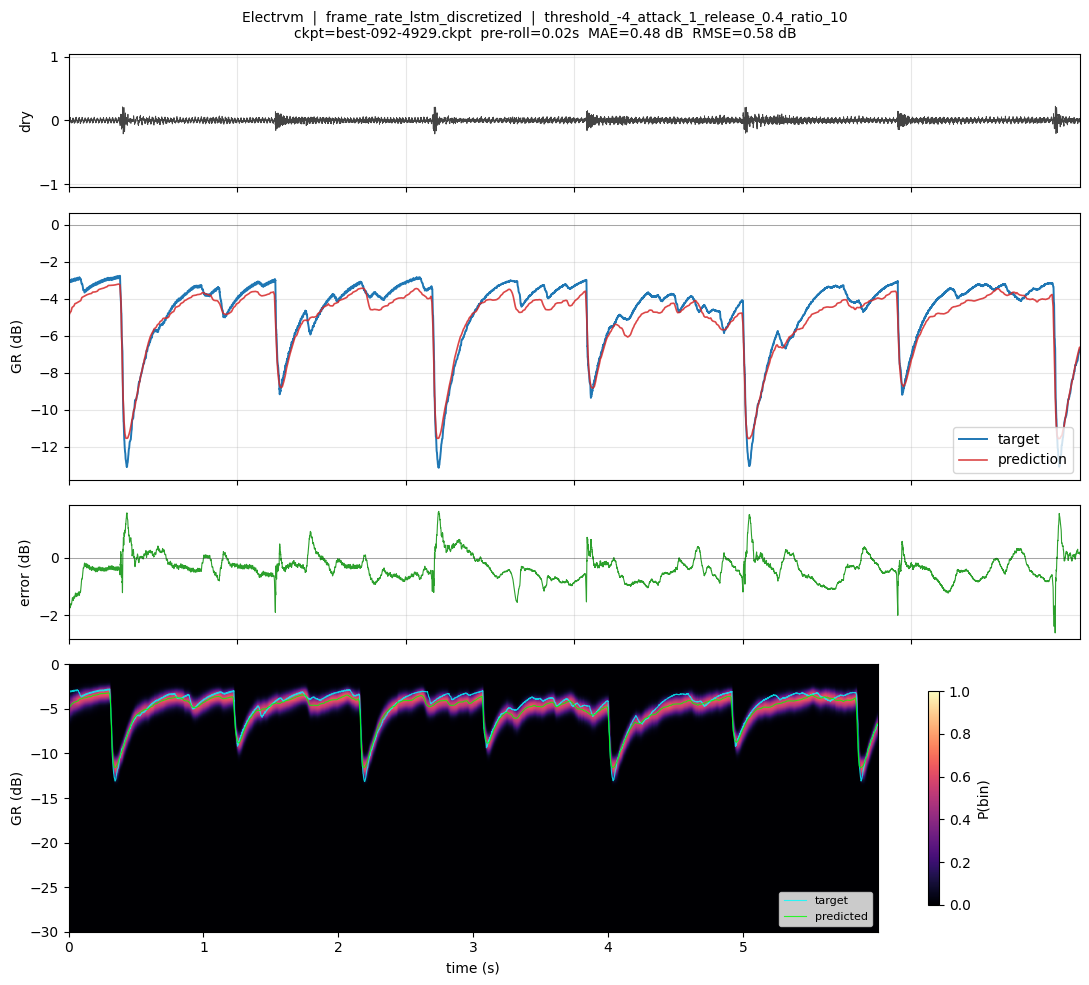

[warning] local src.dsp_torch differs from checkpoint's version
[warning] local src.dsp_torch differs from checkpoint's version


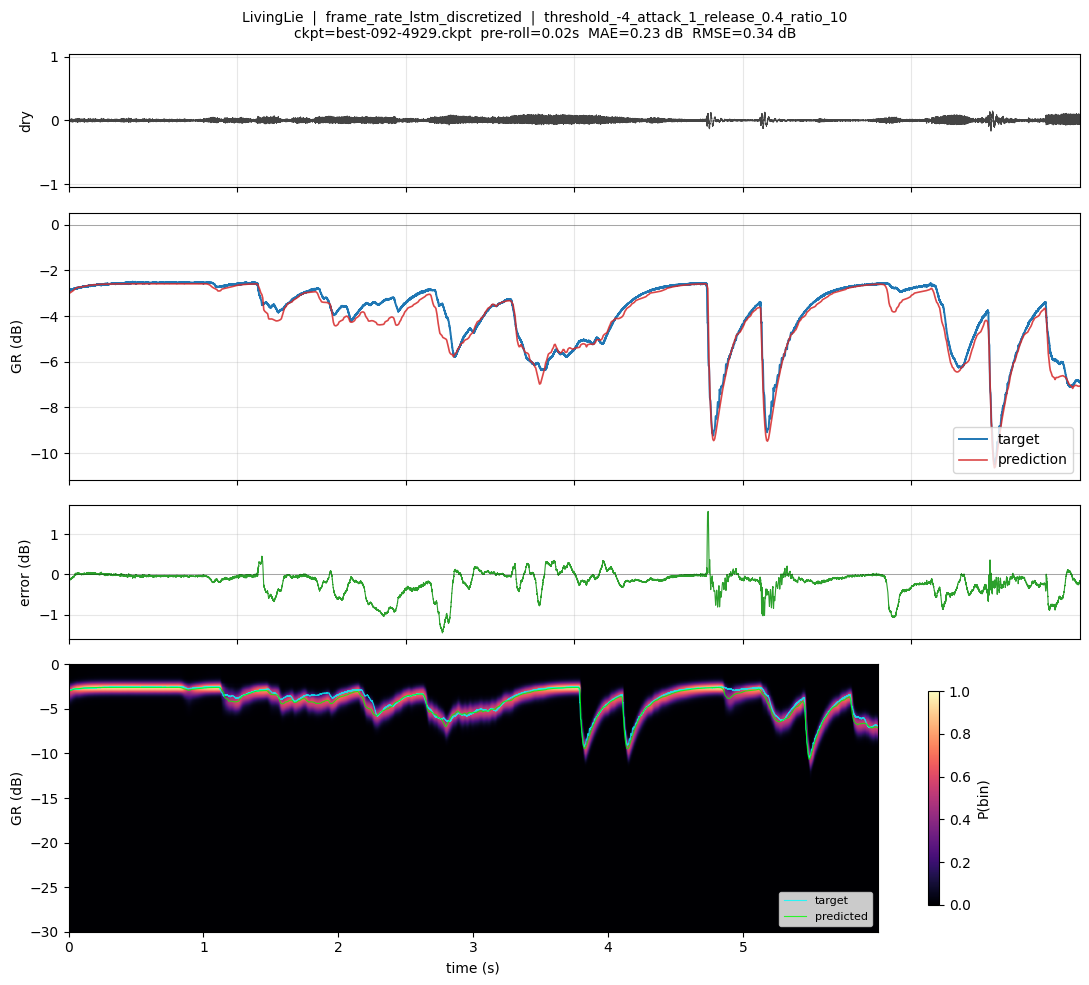

[warning] local src.dsp_torch differs from checkpoint's version
[warning] local src.dsp_torch differs from checkpoint's version


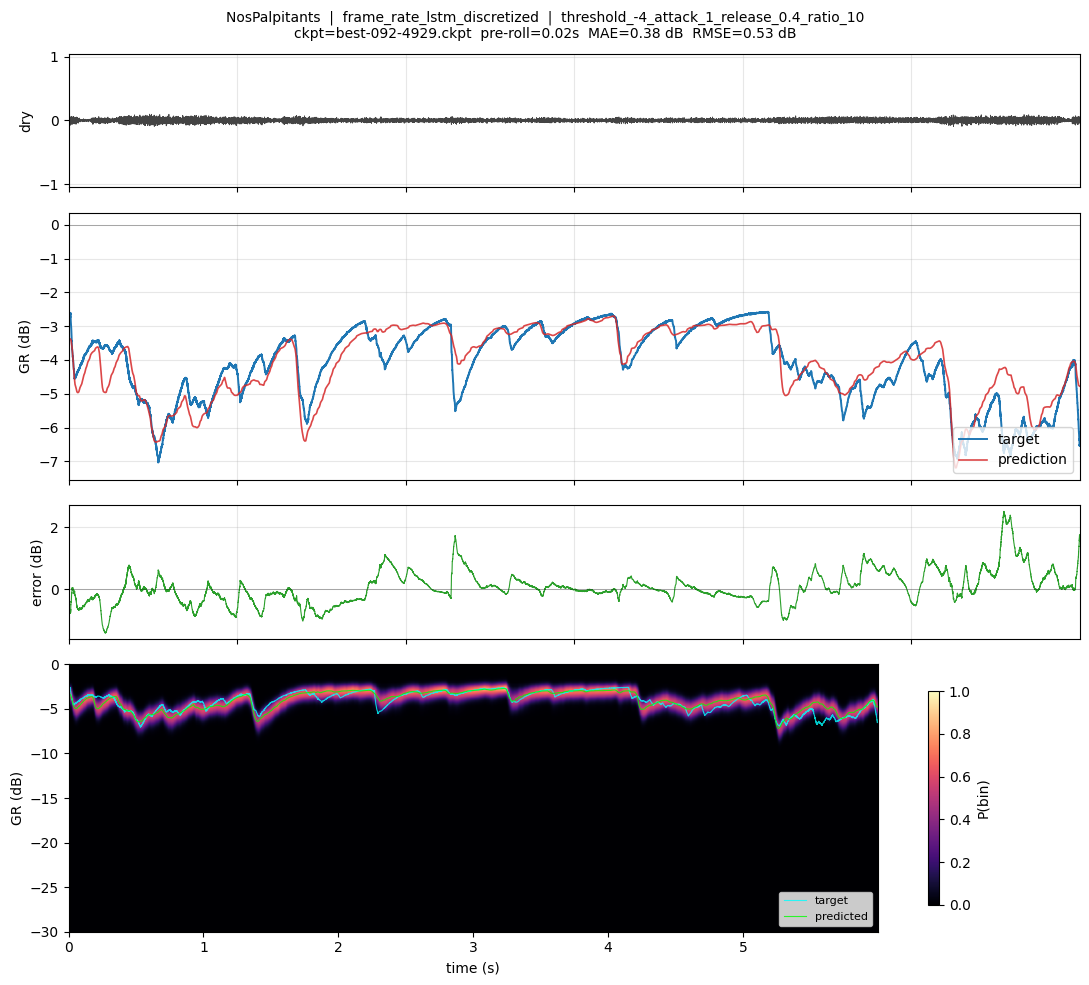

In [9]:
# Compare across multiple songs
results = compare_same_setting_curves(
    ckpt_path=EVAL_CKPT_PATH,
    start_sec=20.0,
    duration_sec=6.0,
    max_pairs=3,
)

In [10]:
# Validation-set reconstructed audio metrics (chunked, memory-friendly)
#
# Reconstructs the same song-level validation split used during training,
# predicts GR in chunks, reconstructs wet audio as dry * 10 ** (GR_dB / 20),
# computes metrics per chunk, then reports one duration-weighted validation row.

import gc
from pathlib import Path

import pandas as pd
import soundfile as sf
import torch

from src.losses import compute_all_losses as compute_audio_losses


def _db_to_amplitude(db: torch.Tensor) -> torch.Tensor:
    return torch.pow(10.0, db / 20.0)


@torch.no_grad()
def _predict_segment_gr(
    system,
    dry_context: torch.Tensor,
    context_offset: int,
    target_len: int,
    device: torch.device,
) -> torch.Tensor:
    if hasattr(system.model, "reset_states"):
        system.model.reset_states()

    x = dry_context.unsqueeze(0).to(device)
    with torch.amp.autocast(device_type=device.type, enabled=device.type == "cuda"):
        logits = system(x)
        gr_context_db = system.model.to_db(logits, T=dry_context.shape[-1])
        gr_context_db = gr_context_db.clamp(GR_DB_MIN, GR_DB_MAX)

    start = context_offset
    stop = context_offset + target_len
    return gr_context_db.squeeze(0)[..., start:stop].float().cpu()


def _pair_num_frames(dry_path: str, wet_path: str, sr: int) -> int:
    dry_info = sf.info(dry_path)
    wet_info = sf.info(wet_path)
    if dry_info.samplerate != sr or wet_info.samplerate != sr:
        print(
            f"[warning] {Path(dry_path).stem}: expected {sr} Hz, "
            f"got dry={dry_info.samplerate}, wet={wet_info.samplerate}; "
            "segment offsets assume matching sample rates."
        )
    return min(dry_info.frames, wet_info.frames)


def _song_from_dry_path(dry_path: str) -> str:
    return Path(dry_path).name.replace("_UnmasteredWAV.wav", "")


def _validation_pairs_from_training_split(
    all_pairs: list[tuple[str, str]],
    hp: dict,
) -> list[tuple[str, str]]:
    songs = sorted({_song_from_dry_path(dry_path) for dry_path, _ in all_pairs})
    split_seed = int(hp.get("split_seed", 42))
    train_split = float(hp.get("train_split", 0.8))

    generator = torch.Generator().manual_seed(split_seed)
    perm = torch.randperm(len(songs), generator=generator).tolist()
    n_train = int(len(songs) * train_split)
    n_train = min(max(1, n_train), len(songs) - 1)

    train_songs = {songs[i] for i in perm[:n_train]}
    val_songs = set(songs) - train_songs

    print(
        f"Validation split: {len(val_songs)} validation songs, "
        f"{len(train_songs)} train songs (seed={split_seed}, train_split={train_split})"
    )
    print(f"Validation songs: {sorted(val_songs)}")

    return [
        (dry_path, wet_path)
        for dry_path, wet_path in all_pairs
        if _song_from_dry_path(dry_path) in val_songs
    ]


from eval_helpers import (
    _db_to_amplitude,
    _pair_num_frames,
    _song_from_dry_path,
    _validation_pairs_from_training_split,
    _weighted_average_metric_rows,
)


# Leave as None to evaluate the full validation split. Use a small integer for
# a quick smoke test, or list validation song names for a subset.
MAX_VALIDATION_SONGS: int | None = None
EVAL_VALIDATION_SONGS: list[str] | None = None

# Smaller chunks reduce peak memory. Increase if you want faster evaluation and
# have RAM/VRAM headroom. Pre-roll gives the LSTM context before each chunk.
WHOLE_SONG_CHUNK_SEC = 10.0
WHOLE_SONG_PRE_ROLL_SEC = None  # None uses the model receptive field.
SAVE_CHUNK_METRICS = False

system, hp = load_system_from_ckpt(EVAL_CKPT_PATH, HPARAMS_PATH)
sr = int(hp["sample_rate"])
device = torch.device(DEVICE)
chunk_frames = int(round(WHOLE_SONG_CHUNK_SEC * sr))
rf_samples = int(hp.get("lstm", {}).get("hop_size", 256)) * 4
pre_roll_frames = rf_samples if WHOLE_SONG_PRE_ROLL_SEC is None else int(round(WHOLE_SONG_PRE_ROLL_SEC * sr))
metric_cols = ["MAE (L1)", "MSE (L2)", "ESR", "MR-STFT", "EDC", "M_NRMSE", "M_SF"]

all_pairs = same_setting_pairs(DATA_ROOT, hp["setting"])
eval_pairs = _validation_pairs_from_training_split(all_pairs, hp)

if EVAL_VALIDATION_SONGS is not None:
    selected_names = set(EVAL_VALIDATION_SONGS)
    eval_pairs = [
        (dry_path, wet_path)
        for dry_path, wet_path in eval_pairs
        if _song_from_dry_path(dry_path) in selected_names
    ]

if MAX_VALIDATION_SONGS is not None:
    eval_pairs = eval_pairs[:MAX_VALIDATION_SONGS]

assert eval_pairs, "No validation pairs selected for evaluation."

validation_chunk_rows = []
for song_idx, (dry_path, wet_path) in enumerate(eval_pairs, start=1):
    song = _song_from_dry_path(dry_path)
    total_frames = _pair_num_frames(dry_path, wet_path, sr)
    print(
        f"[{song_idx}/{len(eval_pairs)}] Evaluating validation song {song} "
        f"({total_frames / sr:.1f}s, chunks of {WHOLE_SONG_CHUNK_SEC:.1f}s)"
    )

    for chunk_idx, start in enumerate(range(0, total_frames, chunk_frames), start=1):
        stop = min(start + chunk_frames, total_frames)
        context_start = max(0, start - pre_roll_frames)
        context_offset = start - context_start

        dry_context, wet_context = _read_dry_wet_segment(
            dry_path,
            wet_path,
            context_start,
            stop,
            sr,
        )
        target_len = min(
            stop - start,
            dry_context.shape[-1] - context_offset,
            wet_context.shape[-1] - context_offset,
        )
        if target_len <= 0:
            continue

        dry_chunk = dry_context[..., context_offset : context_offset + target_len]
        wet_chunk = wet_context[..., context_offset : context_offset + target_len]
        gr_pred_db = _predict_segment_gr(
            system,
            dry_context,
            context_offset,
            target_len,
            device,
        )
        pred_wet = dry_chunk * _db_to_amplitude(gr_pred_db)

        losses = compute_audio_losses(pred_wet.unsqueeze(0), wet_chunk.unsqueeze(0))
        validation_chunk_rows.append({
            "Song": song,
            "Chunk": chunk_idx,
            "Start (s)": start / sr,
            "Duration (s)": target_len / sr,
            "Frames": target_len,
            **losses,
        })

        del dry_context, wet_context, dry_chunk, wet_chunk, gr_pred_db, pred_wet
        if device.type == "cuda":
            torch.cuda.empty_cache()

    gc.collect()

assert validation_chunk_rows, "No validation chunks were evaluated."

weighted_metrics = _weighted_average_metric_rows(validation_chunk_rows, metric_cols)
total_frames = sum(row["Frames"] for row in validation_chunk_rows)
validation_metrics_df = pd.DataFrame([
    {
        "Split": "validation",
        "Songs": len(eval_pairs),
        "Chunks": len(validation_chunk_rows),
        "Duration (s)": total_frames / sr,
        **weighted_metrics,
    }
])

validation_metrics_path = Path(RUN_DIR) / "eval_audio_metrics_validation.csv"
validation_metrics_df.to_csv(validation_metrics_path, index=False)
print(f"Saved validation audio metrics -> {validation_metrics_path}")

if SAVE_CHUNK_METRICS:
    chunk_metrics_path = Path(RUN_DIR) / "eval_audio_metrics_validation_chunks.csv"
    pd.DataFrame(validation_chunk_rows).to_csv(chunk_metrics_path, index=False)
    print(f"Saved validation chunk audio metrics -> {chunk_metrics_path}")

display(validation_metrics_df)

[warning] local src.dsp_torch differs from checkpoint's version
Validation split: 2 validation songs, 8 train songs (seed=42, train_split=0.8)
Validation songs: ['Borderline', 'NosPalpitants']
[1/2] Evaluating validation song Borderline (273.9s, chunks of 10.0s)
[2/2] Evaluating validation song NosPalpitants (198.1s, chunks of 10.0s)
Saved validation audio metrics -> /Volumes/Saola's Drive/AllCode/thesis/data/gr_pred_runs/lstm_gr_20260520_121432_lstm_v3_discretized/eval_audio_metrics_validation.csv


,Split,Songs,Chunks,Duration (s),MAE (L1),MSE (L2),ESR,MR-STFT,EDC,M_NRMSE,M_SF
0,validation,2,48,471.969365,0.00179,0.000007,0.034083,0.091866,0.188338,0.115815,0.140327
